In [422]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from collections import Counter

In [423]:
class NearestNeighbors:
    def __init__(self, k=3, image_size=(28, 28), random_state=42):
        self.k = k
        self.image_size = image_size
        self.random_state = random_state

        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None

        self.train_files = []
        self.test_files = []

    def _extract_label_from_filename(self, filename):
        base_name = os.path.basename(filename)
        match = re.match(r"(\d)", base_name)
        return int(match.group(1)) if match else None

    def _trim_and_center_digit(self, img):
        arr = np.array(img)

        if arr.mean() > 127:
            img = ImageOps.invert(img)
            arr = np.array(img)

        mask = arr > 30

        if not np.any(mask):

            img = img.resize(self.image_size)
            arr = np.array(img).astype(np.float32) / 255.0
            return arr.flatten()

        ys, xs = np.where(mask)
        y_min, y_max = ys.min(), ys.max()
        x_min, x_max = xs.min(), xs.max()

        cropped = arr[y_min:y_max + 1, x_min:x_max + 1]

        h, w = cropped.shape

        target_inner = 20
        if h > w:
            new_h = target_inner
            new_w = max(1, int(w * target_inner / h))
        else:
            new_w = target_inner
            new_h = max(1, int(h * target_inner / w))

        cropped_img = Image.fromarray(cropped)
        resized = cropped_img.resize((new_w, new_h), Image.Resampling.LANCZOS)

        canvas = Image.new("L", self.image_size, color=0)
        paste_x = (self.image_size[0] - new_w) // 2
        paste_y = (self.image_size[1] - new_h) // 2
        canvas.paste(resized, (paste_x, paste_y))

        arr = np.array(canvas).astype(np.float32) / 255.0

        return arr.flatten()

    def _load_image(self, path):
        img = Image.open(path).convert("L")
        return self._trim_and_center_digit(img)

    def load_data(self, folder_path, train_ratio=0.8):
        if not os.path.exists(folder_path):
            raise FileNotFoundError(f"Path not found: {folder_path}")

        X = []
        y = []
        files = []

        for file_name in sorted(os.listdir(folder_path)):
            if not file_name.lower().endswith(".png"):
                continue
            if file_name.startswith("._"):
                continue

            full_path = os.path.join(folder_path, file_name)
            label = self._extract_label_from_filename(file_name)

            if label is None:
                continue

            img = self._load_image(full_path)
            X.append(img)
            y.append(label)
            files.append(full_path)

        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)

        rng = np.random.default_rng(self.random_state)
        indices = np.arange(len(X))
        rng.shuffle(indices)

        X = X[indices]
        y = y[indices]
        files = [files[i] for i in indices]

        split = int(len(X) * train_ratio)

        self.X_train = X[:split]
        self.y_train = y[:split]
        self.X_test = X[split:]
        self.y_test = y[split:]

        self.train_files = files[:split]
        self.test_files = files[split:]

        return self.X_train, self.y_train, self.X_test, self.y_test

    def fit(self, X, y):
        self.X_train = X.astype(np.float32)
        self.y_train = y.astype(np.int32)

    def _predict_single(self, x):
        distances = np.linalg.norm(self.X_train - x, axis=1)

        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        k_distances = distances[k_indices]

        scores = {}
        for label, dist in zip(k_labels, k_distances):
            weight = 1.0 / (dist + 1e-8)
            scores[label] = scores.get(label, 0.0) + weight

        return max(scores.items(), key=lambda item: item[1])[0]

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X], dtype=np.int32)

    def score(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)

    def tune_k(self, candidate_k_values, X_val, y_val):
        best_k = None
        best_acc = -1

        for k in candidate_k_values:
            self.k = k
            acc = self.score(X_val, y_val)
            print(f"k={k} -> {acc * 100:.2f}%")
            if acc > best_acc:
                best_acc = acc
                best_k = k

        self.k = best_k
        print(f"Best k: {best_k}, Best accuracy: {best_acc * 100:.2f}%")
        return best_k, best_acc

    def print_results(self, X, y, files):
        preds = self.predict(X)
        for i in range(min(20, len(X))):
            print(f"File: {os.path.basename(files[i])} | Pred: {preds[i]} | True: {y[i]}")

    def show_image(self, X, y, index=0):
        img = X[index].reshape(self.image_size)
        plt.imshow(img, cmap="gray")
        plt.title(f"Label: {y[index]}")
        plt.axis("off")
        plt.show()

    def show_predictions(self, X, y, count=10):
        preds = self.predict(X)
        count = min(count, len(X))

        cols = 5
        rows = (count + cols - 1) // cols
        plt.figure(figsize=(12, 2.5 * rows))

        for i in range(count):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(X[i].reshape(self.image_size), cmap="gray")
            plt.title(f"T:{y[i]} / P:{preds[i]}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

In [424]:
project_root = os.getcwd()
training_data_path = os.path.join(project_root, "TrainingData")

print("Project root:", project_root)
print("TrainingData path:", training_data_path)
print("TrainingData exists:", os.path.exists(training_data_path))

Project root: /content
TrainingData path: /content/TrainingData
TrainingData exists: True


In [425]:
model = NearestNeighbors(k=3, random_state=42)

X_train, y_train, X_test, y_test = model.load_data(training_data_path)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (109, 784)
Training labels shape: (109,)
Test data shape: (28, 784)
Test labels shape: (28,)


In [426]:
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [427]:
candidate_k_values = [1, 3, 5, 7, 9]
best_k, best_acc = model.tune_k(candidate_k_values, X_test, y_test)

k=1 -> 82.14%
k=3 -> 85.71%
k=5 -> 85.71%
k=7 -> 82.14%
k=9 -> 85.71%
Best k: 3, Best accuracy: 85.71%


In [428]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 85.71%


In [429]:
predictions = model.predict(X_test)

print("First 20 predictions:", predictions[:20])
print("First 20 true labels:", y_test[:20])

First 20 predictions: [3 7 8 4 2 1 4 5 2 5 3 3 0 9 9 0 5 2 7 7]
First 20 true labels: [3 7 8 4 2 2 4 5 2 5 3 3 0 7 9 0 9 2 7 1]


In [430]:
model.print_results(X_test, y_test, model.test_files)

File: 3-test-2.png | Pred: 3 | True: 3
File: 7-test-2.png | Pred: 7 | True: 7
File: 8Solomon.png | Pred: 8 | True: 8
File: 444Nathan.png | Pred: 4 | True: 4
File: 2-test-5.png | Pred: 2 | True: 2
File: 2-test-1.png | Pred: 1 | True: 2
File: 4-test-2.png | Pred: 4 | True: 4
File: 5-test-4.png | Pred: 5 | True: 5
File: 2-test-6.png | Pred: 2 | True: 2
File: 5-test-7.png | Pred: 5 | True: 5
File: 33Nathan.png | Pred: 3 | True: 3
File: 3-test-7.png | Pred: 3 | True: 3
File: 0-test-7.png | Pred: 0 | True: 0
File: 7-test-5.png | Pred: 9 | True: 7
File: 9-test-8.png | Pred: 9 | True: 9
File: 00Nathan.png | Pred: 0 | True: 0
File: 9-test-3.png | Pred: 5 | True: 9
File: 2Nathan.png | Pred: 2 | True: 2
File: 7Solomon.png | Pred: 7 | True: 7
File: 1-test.png | Pred: 7 | True: 1


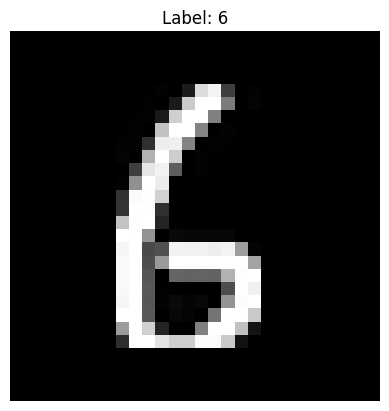

In [431]:
model.show_image(X_train, y_train, index=0)

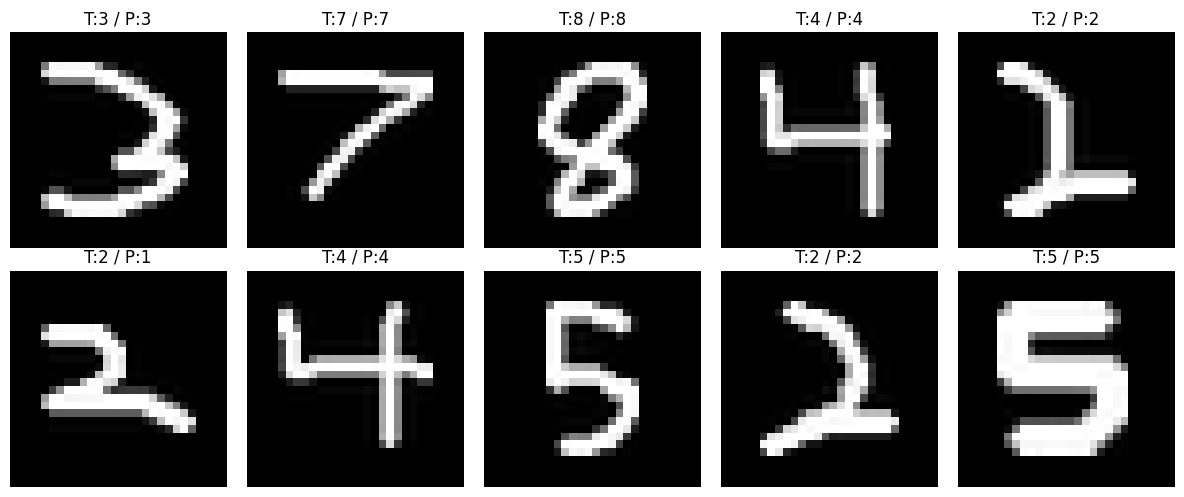

In [421]:
model.show_predictions(X_test, y_test, count=10)